<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - lineare/logistische Regression
</b></font> </br></p>

---


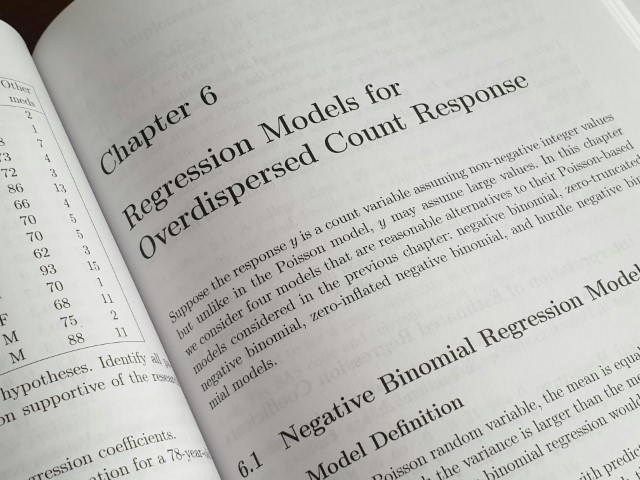

Foto von <a href="https://unsplash.com/de/@raheemsphoto?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Enayet Raheem</a> auf <a href="https://unsplash.com/de/fotos/kapitel-6-regressionsmodelle-fur-uberdisperse-zahlungresponse-buchseite-3RQnQyyzA9c?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>
  

# **0  <font color='orange'>|</font> Install & Import**
***

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import plotly.express as px

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

# **1  <font color='orange'>|</font> Understand**
***

In [ ]:
# Daten laden
df = pd.read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/loan.csv')
data = df.copy()

In [ ]:
# Auswahl der Merkmale und Zielvariable
features = ['age', 'gender', 'occupation', 'education_level', 'marital_status', 'income']
label = 'credit_score'

# Daten bereinigen (z.B. fehlende Werte behandeln)
data = df[features].copy()
target_num = df[label].copy()

In [ ]:
target_kat = df['loan_status'].copy()
target_kat.replace(['Approved', 'Denied'], [1,0], inplace=True)

# **2  <font color='orange'>|</font> Prepare**
***

In [ ]:
data.dropna(inplace=True)
target_num = target_num[data.index]

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include='number').columns
cat_col = data.select_dtypes(exclude='number').columns

In [ ]:
data[cat_col] = OrdinalEncoder().fit_transform(data[cat_col])

# **3  <font color='orange'>|</font> Modeling**
***

In [ ]:
# Lineares Modell erstellen und trainieren
linear_model = LinearRegression()
linear_model.fit(data, target_num)

In [ ]:
# Logistisches Modell erstellen und trainieren
logistic_model = LogisticRegression()
logistic_model.fit(data, target_kat)

# **4  <font color='orange'>|</font> Evaluate**
***


<p><font color='black' size="5">
lineare Regression
</font></p>

In [ ]:
target_pred_linear = linear_model.predict(data)

In [ ]:
r2_train = r2_score(target_num, target_pred_linear)
print(f'Bestimmtheitsmass: {r2_train:5.2f}' )

In [ ]:
mae = mean_absolute_error(target_num, target_pred_linear)
print(f'Mean Absolute Error: {mae:5.2f}' )

In [ ]:
# Ergebnisse der linearen Regression visualisieren
px.scatter(x=data['income'], y=[target_num, target_pred_linear],
    title='Lineare Regression auf Credit Score',
    labels={'x': 'Income', 'y': 'Credit Score'},
    width=800, height=500)

In [ ]:
min(target_num), max(target_num), target_num.mean()

In [ ]:
from yellowbrick.regressor import residuals_plot
_ = residuals_plot(linear_model, data, target_num)

<p><font color='black' size="5">
Überleitung auf Binärklassifikation
</font></p>

In [ ]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

In [ ]:
# Normalisieren der linearen Vorhersagen, damit sie in einem geeigneten Bereich für die Sigmoid-Funktion liegen
normalized_predictions = (target_pred_linear - target_pred_linear.mean()) / 100

# Anwenden der Sigmoid-Funktion auf die linearen Vorhersagen
sigmoid_predictions = sigmoid(normalized_predictions)

# Binärklassifikation anhand eines Schwellenwerts (z.B. 0.5)
binary_predictions = (sigmoid_predictions > 0.5).astype(int)

In [ ]:
acc_lin = accuracy_score(target_kat, binary_predictions) * 100
print (f"Accuracy: {acc_lin:5.2f}%")

In [ ]:
conf_matrix_lin = confusion_matrix(target_kat, binary_predictions)
display_labels_=['No','Yes']
disp = ConfusionMatrixDisplay(conf_matrix_lin, display_labels=display_labels_)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_kat, target_pred_logistic, target_names=display_labels_))

<p><font color='black' size="5">
Logistische Regression
</font></p>

In [ ]:
# Vorhersagen erstellen
target_pred_logistic = logistic_model.predict(data)

In [ ]:
acc_log = accuracy_score(target_kat, target_pred_logistic) * 100
print (f"Accuracy: {acc_log:5.2f}%")

In [ ]:
conf_matrix_log = confusion_matrix(target_kat, target_pred_logistic)
display_labels_=['No','Yes']
disp = ConfusionMatrixDisplay(conf_matrix_log, display_labels=display_labels_)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_kat, target_pred_logistic, target_names=display_labels_))

# **5  <font color='orange'>|</font> Deploy**
***